# Problem statement

In [ ]:
#predict exact price of laptop based on various features

# Import libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt
%matplotlib inline
import warnings 
warnings.filterwarnings('ignore')

# read dataset

In [2]:
data=pd.read_csv('Laptop_price.csv')
data

,Brand,Processor_Speed,RAM_Size,Storage_Capacity,Screen_Size,Weight,Price
0,Asus,3.830296,16,512,11.185147,2.641094,17395.093065
1,Acer,2.912833,4,1000,11.311372,3.260012,31607.605919
2,Lenovo,3.241627,4,256,11.853023,2.029061,9291.023542
3,Acer,3.806248,16,512,12.280360,4.573865,17436.728334
4,Acer,3.268097,32,1000,14.990877,4.193472,32917.990718
...,...,...,...,...,...,...,...
995,HP,3.343584,4,1000,12.587095,3.162399,31593.668017
996,Dell,2.780555,8,256,12.679356,3.750265,9149.521832
997,Dell,3.200569,4,512,12.666315,3.392612,16552.404779
998,Asus,1.604182,8,256,11.215581,3.857613,9407.473459


# Basic checks

In [3]:
data.head()

,Brand,Processor_Speed,RAM_Size,Storage_Capacity,Screen_Size,Weight,Price
0,Asus,3.830296,16,512,11.185147,2.641094,17395.093065
1,Acer,2.912833,4,1000,11.311372,3.260012,31607.605919
2,Lenovo,3.241627,4,256,11.853023,2.029061,9291.023542
3,Acer,3.806248,16,512,12.280360,4.573865,17436.728334
4,Acer,3.268097,32,1000,14.990877,4.193472,32917.990718


In [4]:
data.tail()

,Brand,Processor_Speed,RAM_Size,Storage_Capacity,Screen_Size,Weight,Price
995,HP,3.343584,4,1000,12.587095,3.162399,31593.668017
996,Dell,2.780555,8,256,12.679356,3.750265,9149.521832
997,Dell,3.200569,4,512,12.666315,3.392612,16552.404779
998,Asus,1.604182,8,256,11.215581,3.857613,9407.473459
999,Lenovo,1.711980,4,256,16.561498,3.440883,8807.696702


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Brand             1000 non-null   object 
 1   Processor_Speed   1000 non-null   float64
 2   RAM_Size          1000 non-null   int64  
 3   Storage_Capacity  1000 non-null   int64  
 4   Screen_Size       1000 non-null   float64
 5   Weight            1000 non-null   float64
 6   Price             1000 non-null   float64
dtypes: float64(4), int64(2), object(1)
memory usage: 54.8+ KB


In [6]:
data.shape

(1000, 7)

In [7]:
#we have 1000 rows with 7 columns
#Price is our taget column

In [8]:
data.describe()

,Processor_Speed,RAM_Size,Storage_Capacity,Screen_Size,Weight,Price
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,2.750611,15.500000,584.576000,14.056790,3.466919,19604.187963
std,0.731796,10.988665,313.438517,1.705882,0.866541,9406.064880
min,1.511580,4.000000,256.000000,11.012111,2.000560,8570.012950
25%,2.089246,8.000000,256.000000,12.635523,2.717211,10114.012948
50%,2.760885,16.000000,512.000000,14.099643,3.464630,17287.241878
75%,3.362610,32.000000,1000.000000,15.528590,4.212583,31566.214754
max,3.998534,32.000000,1000.000000,16.985737,4.990728,33503.935037


In [9]:
#there are no null values

In [10]:
data.describe(include='O')

,Brand
count,1000
unique,5
top,Dell
freq,210


In [11]:
#we have 5 brands laptop data

# Domain Analysis

In [12]:
data.head()

,Brand,Processor_Speed,RAM_Size,Storage_Capacity,Screen_Size,Weight,Price
0,Asus,3.830296,16,512,11.185147,2.641094,17395.093065
1,Acer,2.912833,4,1000,11.311372,3.260012,31607.605919
2,Lenovo,3.241627,4,256,11.853023,2.029061,9291.023542
3,Acer,3.806248,16,512,12.280360,4.573865,17436.728334
4,Acer,3.268097,32,1000,14.990877,4.193472,32917.990718


**Brand** := Laptop manufacturer (e.g., Acer, Asus, Lenovo). May impact price based on brand value, support, and quality.

**Processor_Speed** := Speed of the processor in GHz (approx). Higher speed → generally better performance → higher price.

**RAM_Size** :=	RAM size in GB. More RAM improves multitasking and performance.

**Storage_Capacity** :=	Internal storage (likely in GB). Higher storage is often associated with premium pricing.

**Screen_Size**	:= Size of the display in inches. Larger screens typically cost more and are considered more premium.

**Weight** := Weight of the laptop in kg. Lightweight laptops may be priced higher (ultrabooks), but not always.

# EDA

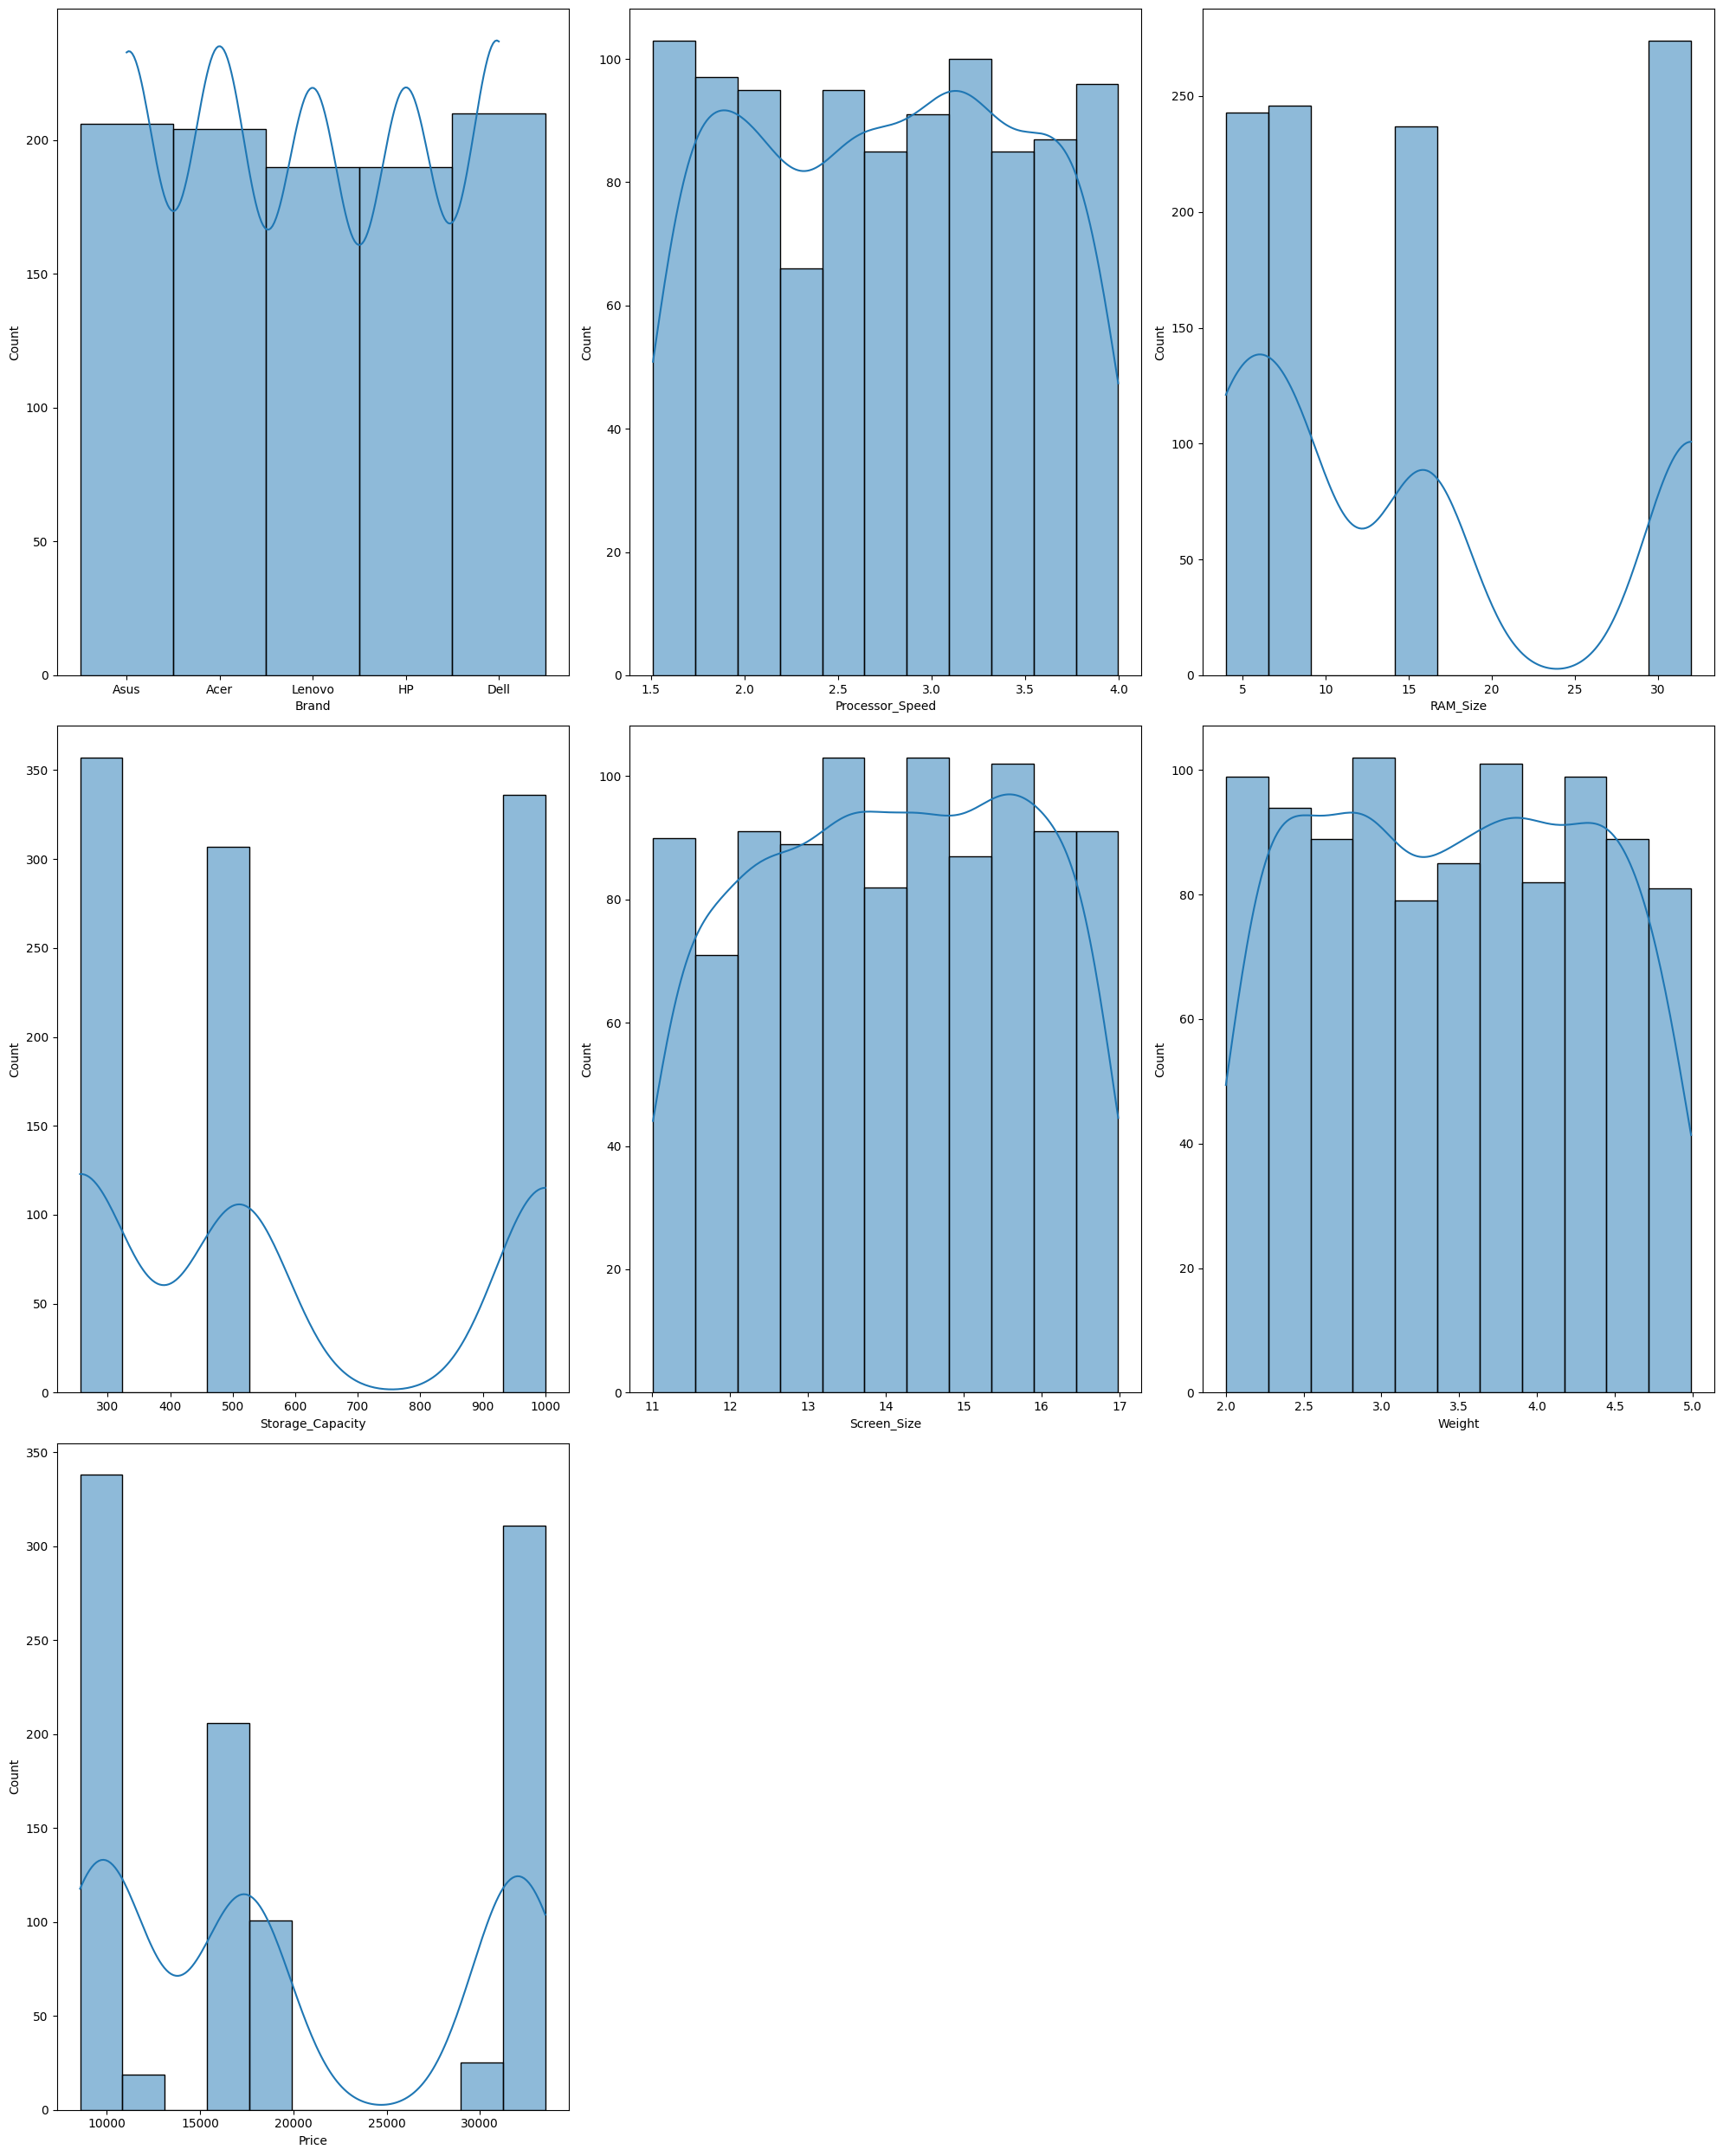

In [16]:
plotn=1
plt.figure(figsize=(20,25),facecolor='white')
for i in data.columns:
    if plotn<=7:
        ax=plt.subplot(3,3,plotn)
        sns.histplot(x=data[i],data=data,kde=True)
    plotn+=1
plt.tight_layout()
plt.show()

In [25]:
#In Brand count of dell is higher than others
#In Price it seems like there are more low budget laptops than high bugdet 


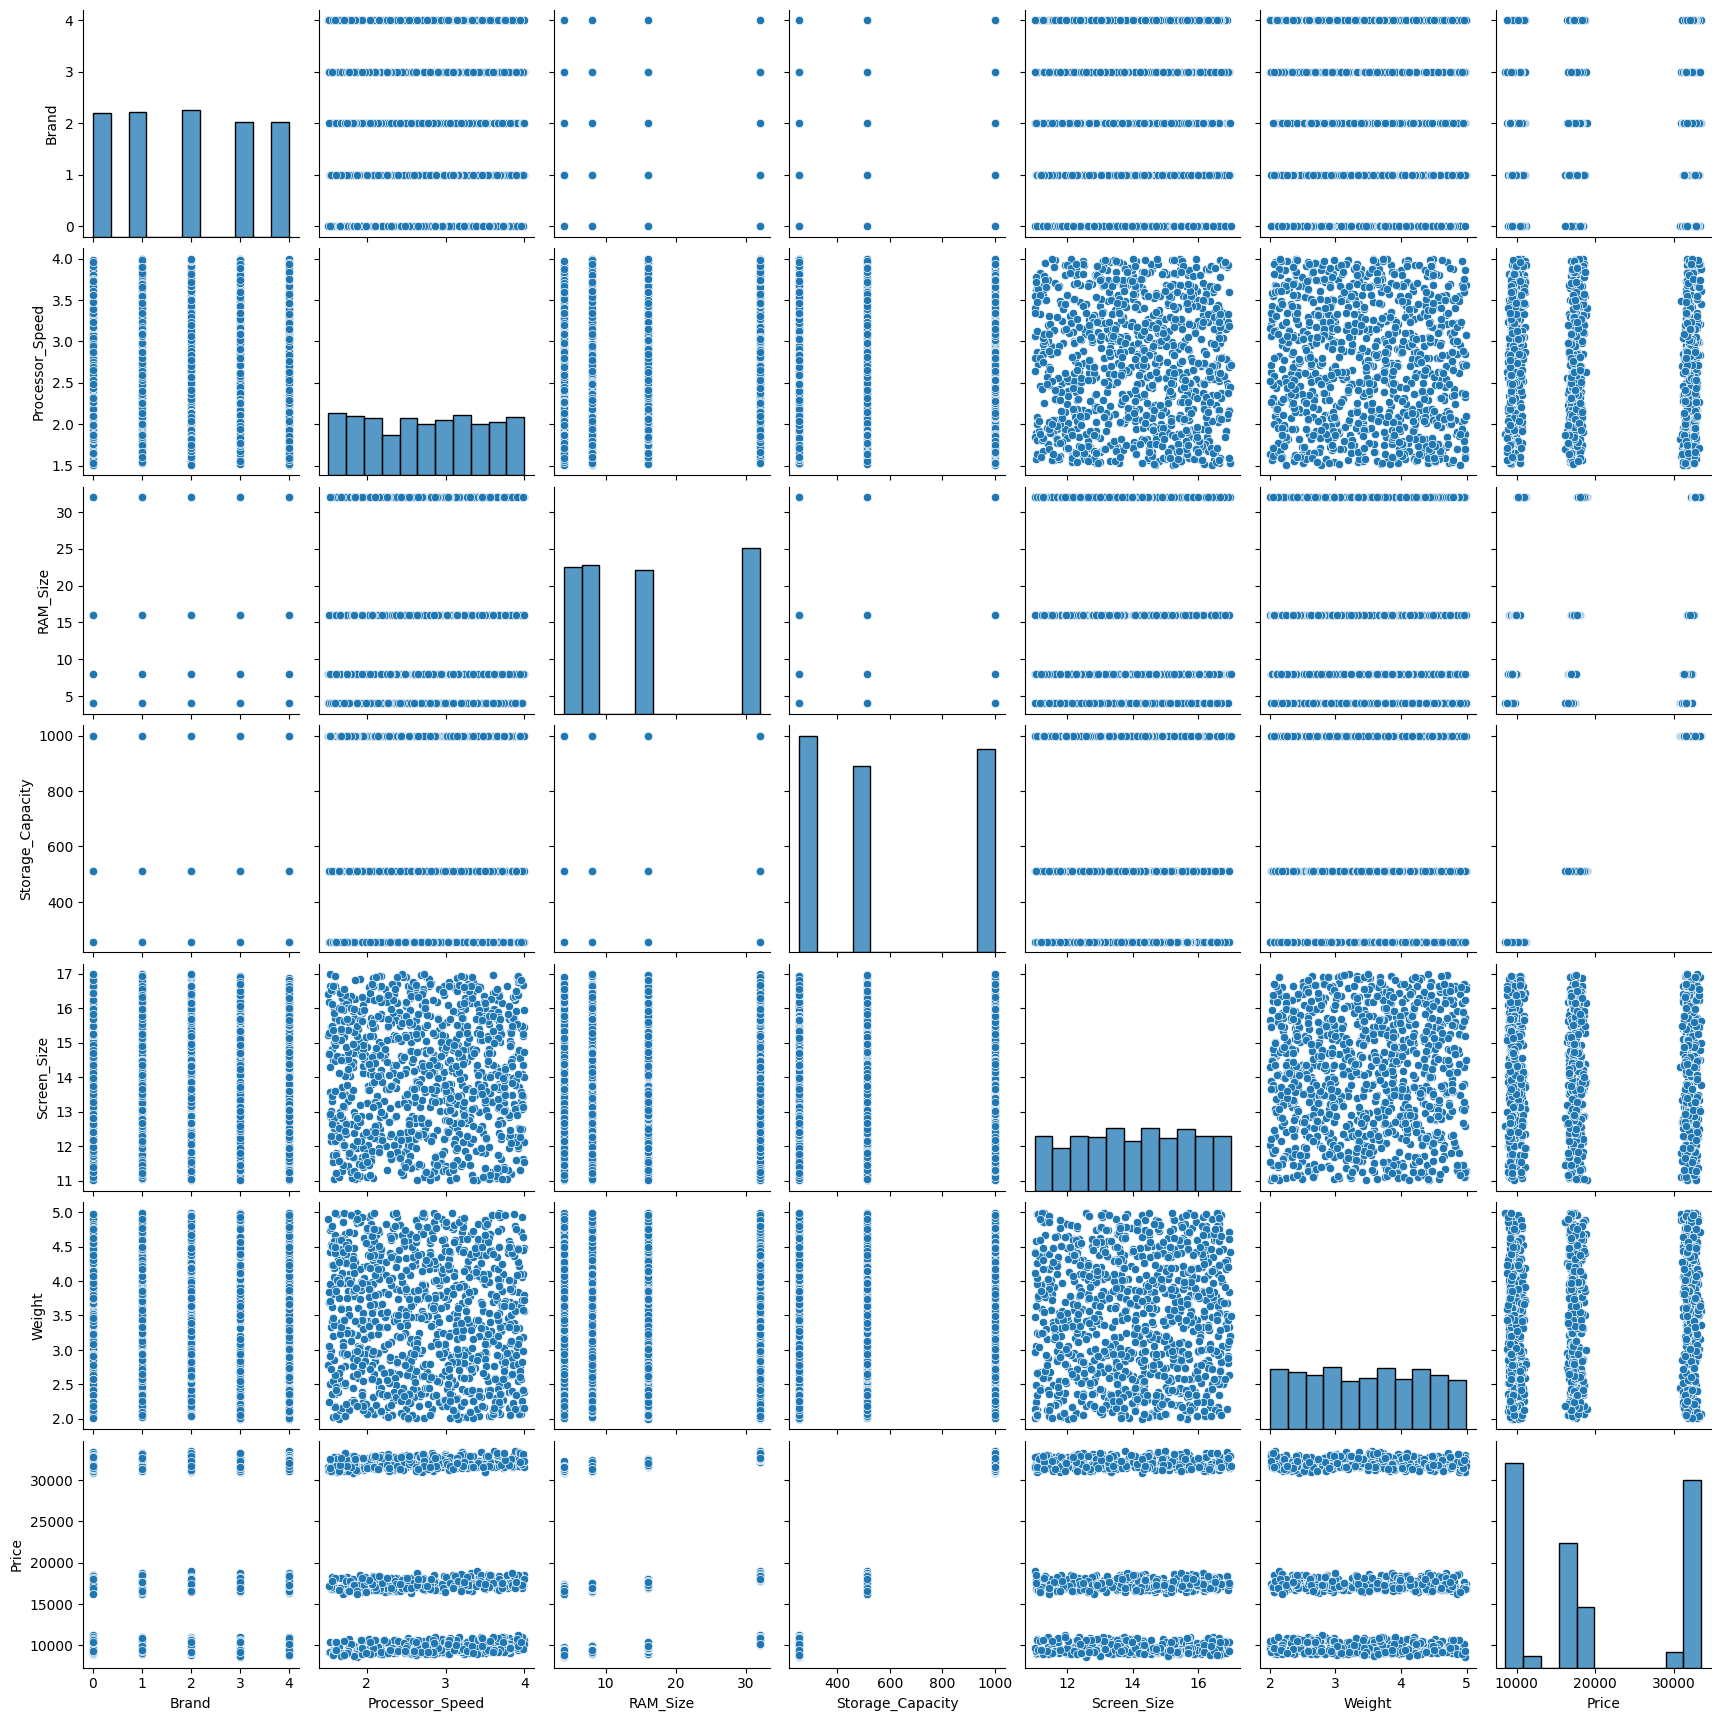

In [57]:
sns.pairplot(data)
plt.show()

# data preprocessing

In [26]:
data.isnull().sum()

Brand               0
Processor_Speed     0
RAM_Size            0
Storage_Capacity    0
Screen_Size         0
Weight              0
Price               0
dtype: int64

In [27]:
#there are no null values

In [28]:
data.duplicated().sum()

0

In [29]:
#there is no duplicate data

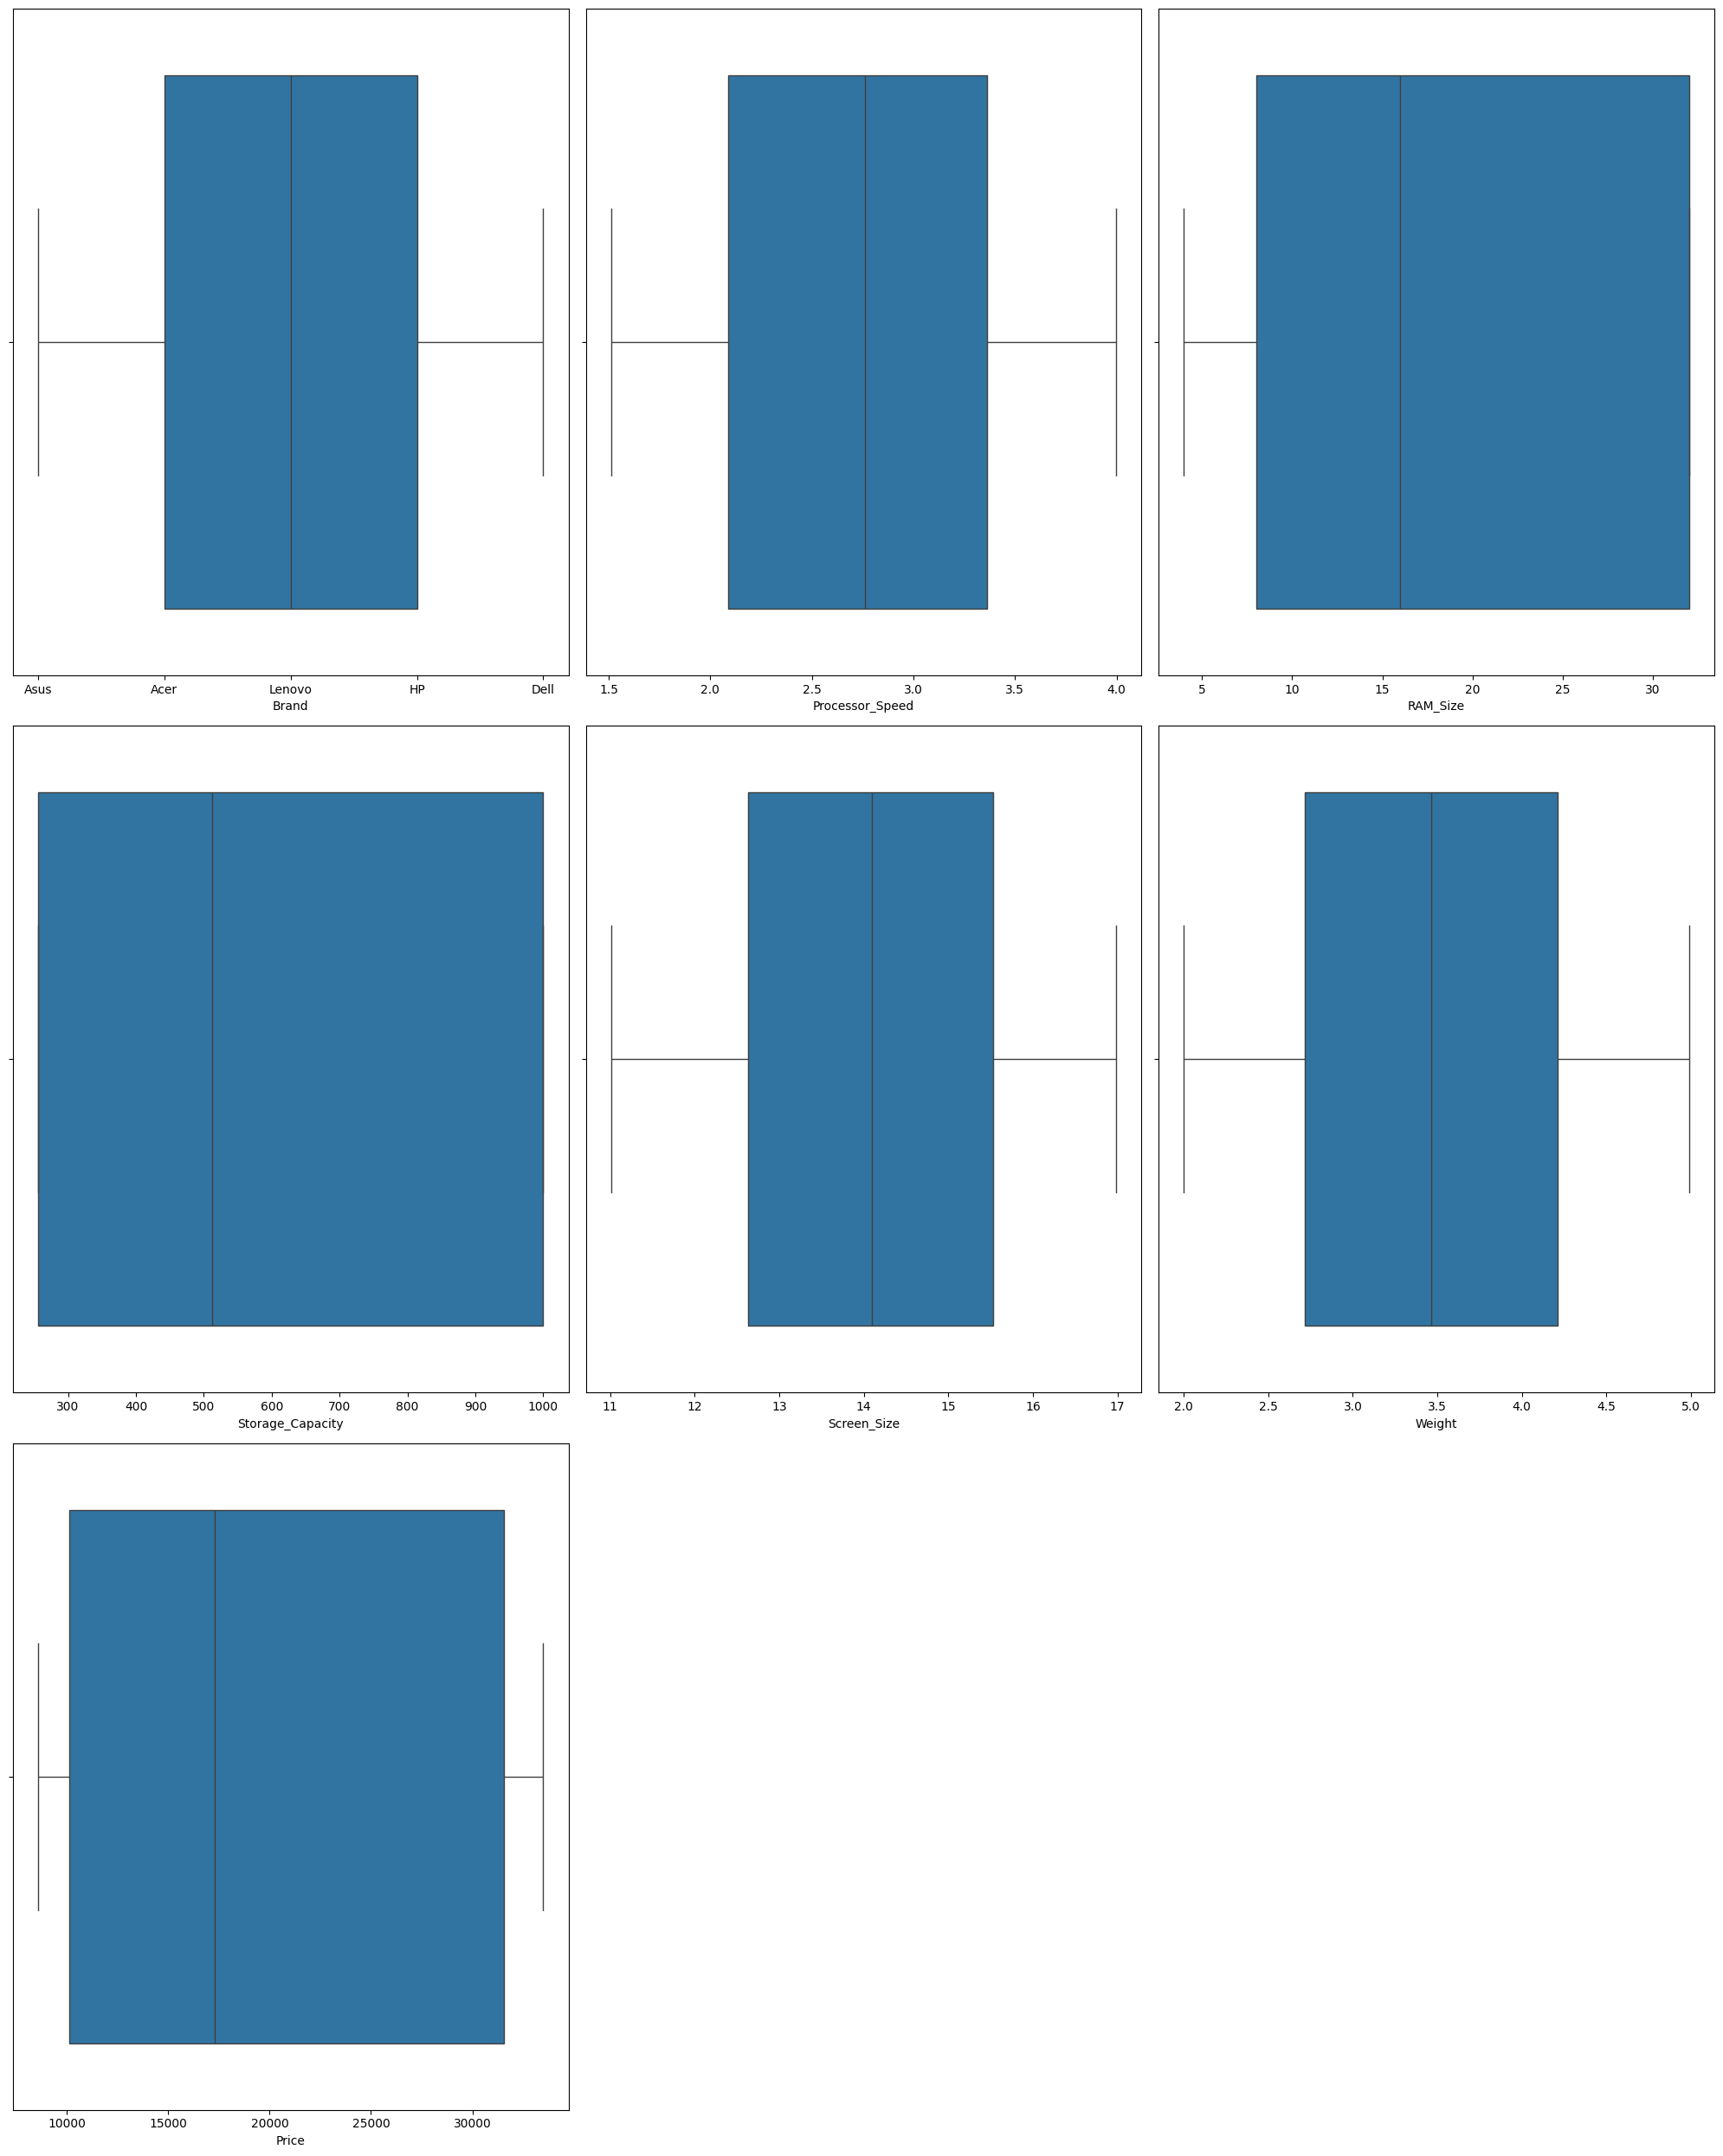

In [30]:
plotn=1
plt.figure(figsize=(20,25),facecolor='white')
for i in data.columns:
    if plotn<=7:
        ax=plt.subplot(3,3,plotn)
        sns.boxplot(x=data[i],data=data)
    plotn+=1
plt.tight_layout()
plt.show()

In [31]:
#it shows there are no outliers

In [33]:
from sklearn.preprocessing import LabelEncoder
lc=LabelEncoder()
data.Brand=lc.fit_transform(data.Brand)

In [35]:
from scipy.stats import skew
print(skew(data['Price']))

0.36573113896423737


In [36]:
#Price is not skewed so we dont need any transformation

# Feature Engineering

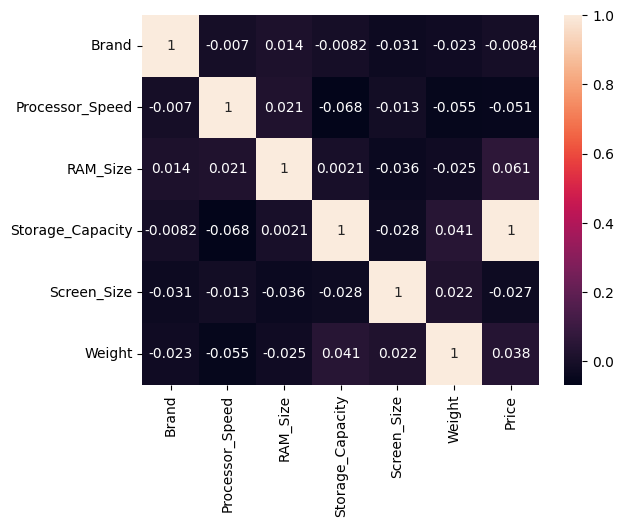

In [38]:
sns.heatmap(data.corr().drop('Price'),annot=True)
plt.show()

In [39]:
#no correlation is <0.9 or >-0.9

In [40]:
X=data.drop('Price',axis=1)
y=data.Price

# Spliting data

In [41]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=42)

In [43]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X_train_scaled=sc.fit_transform(X_train)
X_test_scaled=sc.transform(X_test)

# Model Creation

In [44]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(X_train_scaled,y_train)

LinearRegression()

In [45]:
y_pred=model.predict(X_test_scaled)

# Model Evaluation

In [46]:
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error
r2score=r2_score(y_test,y_pred)

In [47]:
r2score

0.9996098185376979

In [48]:
X_train_scaled.shape

(750, 6)

In [49]:
## calculation of adjusted r2 score
adjusted_r2 = 1-((1-0.9996098185376979)*(750-1)/(750-6-1))
adjusted_r2

0.9996066676779755

In [50]:
#r2 score is less than adj.r2 score so our model is working well 

In [51]:
import math
print(mean_squared_error(y_test,y_pred))

34321.95639172259


In [52]:
print(math.sqrt(mean_squared_error(y_test,y_pred))) # root mean squared error

185.2618589772935


In [53]:
print(mean_absolute_error(y_test,y_pred))

150.6058429466695


In [54]:
y_pred_train=model.predict(X_train_scaled)

In [56]:
r2score_training=r2_score(y_train,y_pred_train)
r2score

0.9996098185376979